## 1. Import Libraries and Load Cleaned Data

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import RobustScaler, OrdinalEncoder,OneHotEncoder
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Lasso
from xgboost import XGBRegressor

from module_function import (cross_validate_model,plot_all_modelsRegression_predictions,
                             evaluate_models_Regression,feature_importance,plot_residuals,Hyperparameter_Tuning,plot_tuned_feature_importance)

import warnings
warnings.filterwarnings("ignore")

import pickle

In [20]:
df = pd.read_csv('dataset/amazon_delivery_CLEANING.csv')
df_x = df.drop(columns='Delivery_Time')
df_y = df['Delivery_Time']

In [21]:
X_train,X_test,y_train,y_test = train_test_split(df_x,df_y,test_size=0.2,random_state=42)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 28075 samples
Test set: 7019 samples


## 2. Feature Scaling

In [22]:
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns

base_preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), num_cols),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols)
    ]
)

In [23]:
## 3.Pipeline All Models Regression

In [24]:
n = 17
regresi_pipelines = {
    'Linear Regression': Pipeline([
        ('preprocessing', base_preprocessor),
        ('feature_selection', SelectKBest(score_func=f_regression, k=n)),
        ('model', LinearRegression())
    ]),
    
    'Ridge Regression': Pipeline([
        ('preprocessing', base_preprocessor),
        ('feature_selection', SelectKBest(score_func=f_regression, k=n)),
        ('model', Ridge(alpha=1.0))
    ]),
    
    'Lasso Regression': Pipeline([
        ('preprocessing', base_preprocessor),
        ('feature_selection', SelectKBest(score_func=f_regression, k=n)),
        ('model', Lasso(alpha=1.0, random_state=42, max_iter=10000))
    ]),
    
    'Random Forest Regressor': Pipeline([
        ('preprocessing', base_preprocessor),
        ('feature_selection', SelectKBest(score_func=f_regression, k=n)),
        ('model', RandomForestRegressor(random_state=42))
    ]),
    
    'Gradient Boosting Regressor': Pipeline([
        ('preprocessing', base_preprocessor),
        ('feature_selection', SelectKBest(score_func=f_regression, k=n)),
        ('model', GradientBoostingRegressor(random_state=42))
    ]),
    
    'XGBoost Regressor': Pipeline([
        ('preprocessing', base_preprocessor),
        ('feature_selection', SelectKBest(score_func=f_regression, k=n)),
        ('model', XGBRegressor(random_state=42, n_estimators=100, learning_rate=0.1))
    ])
}

## 4.Analysis Model Sebelum Cross-Validate

In [25]:
predictions_dict = {}
for model_name, pipeline in regresi_pipelines.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    predictions_dict[model_name] = y_pred

df_report = evaluate_models_Regression( model_dict=predictions_dict, y_test=y_test)
df_report.sort_values(by='R2-Score', ascending=False)

Menguji model: Linear Regression
Menguji model: Ridge Regression
Menguji model: Lasso Regression
Menguji model: Random Forest Regressor
Menguji model: Gradient Boosting Regressor
Menguji model: XGBoost Regressor

Proses Training Selesai!


,Model,R2-Score,MAE,MSE,RMSE
5,XGBoost Regressor,0.8029,17.8967,526.5323,22.9463
3,Random Forest Regressor,0.7749,18.9299,601.1509,24.5184
4,Gradient Boosting Regressor,0.7570,20.0601,649.0063,25.4756
1,Ridge Regression,0.2950,33.3801,1883.1446,43.3952
0,Linear Regression,0.2949,33.3795,1883.3134,43.3972
2,Lasso Regression,0.2869,33.6630,1904.8129,43.6442


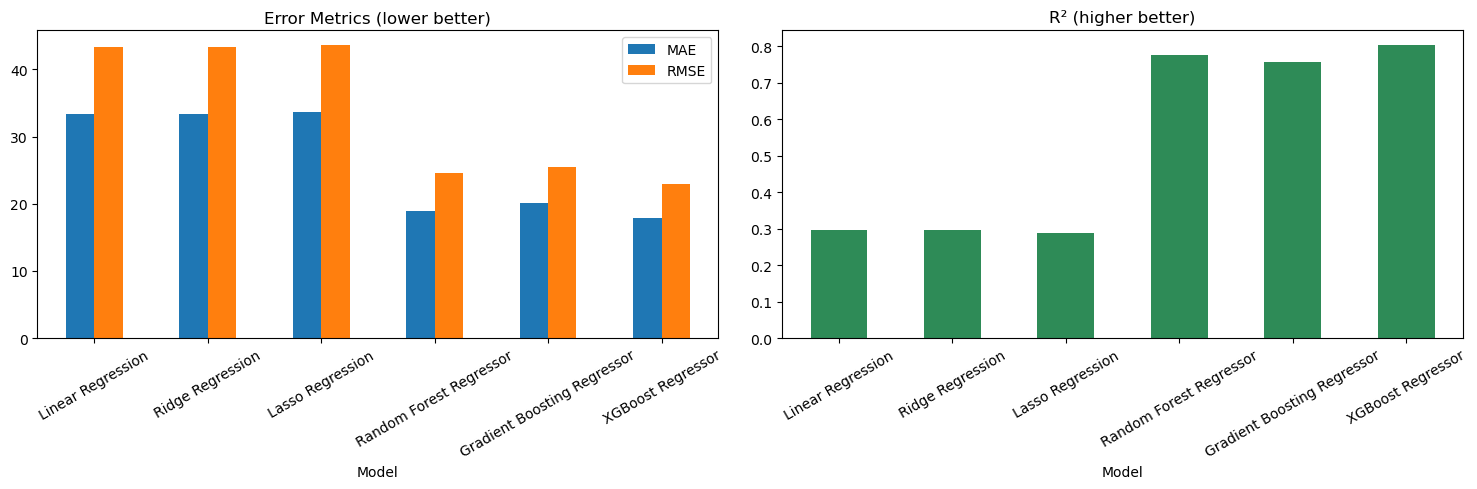

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
df_report.set_index('Model')[['MAE', 'RMSE']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Error Metrics (lower better)')
axes[0].tick_params(axis='x', rotation=30)

df_report.set_index('Model')[['R2-Score']].plot(kind='bar', ax=axes[1], color='seagreen', legend=False)
axes[1].set_title('R² (higher better)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 5.Analysis Model Sesudah Cross-Validate

In [28]:
df_hasil_perbandingan = cross_validate_model(models_dict=regresi_pipelines, X=X_train, y=y_train, cv_folds=5, mode='regression')
df_hasil_perbandingan.sort_values(by='R2-Score', ascending=False)

=== MENJALANKAN 5-FOLD CROSS VALIDATION (REGRESI) ===

Menguji model: Linear Regression
Menguji model: Ridge Regression
Menguji model: Lasso Regression
Menguji model: Random Forest Regressor
Menguji model: Gradient Boosting Regressor
Menguji model: XGBoost Regressor

Proses CV Selesai!


,Model,R2-Score,MAE,MSE,RMSE
5,XGBoost Regressor,0.806123,17.749773,515.459351,22.703730
3,Random Forest Regressor,0.771867,19.075016,606.647929,24.630224
4,Gradient Boosting Regressor,0.770218,19.507918,610.976608,24.717941
0,Linear Regression,0.305290,33.017096,1847.134013,42.978297
1,Ridge Regression,0.305284,33.018752,1847.148429,42.978465
2,Lasso Regression,0.294635,33.402198,1875.450126,43.306467


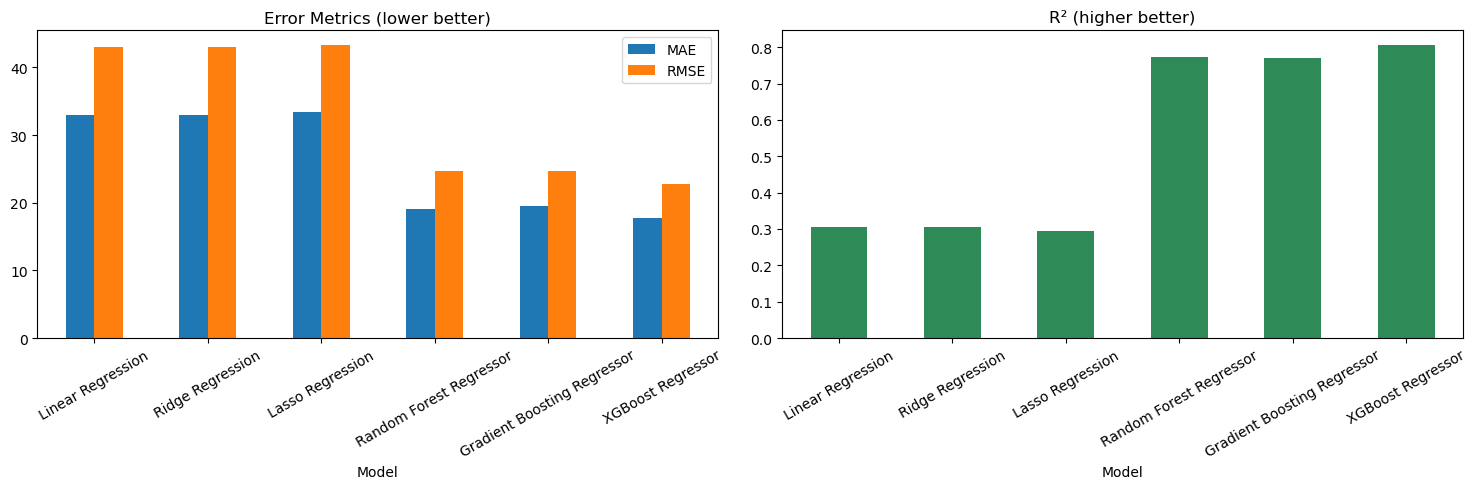

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
df_hasil_perbandingan.set_index('Model')[['MAE', 'RMSE']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Error Metrics (lower better)')
axes[0].tick_params(axis='x', rotation=30)

df_hasil_perbandingan.set_index('Model')[['R2-Score']].plot(kind='bar', ax=axes[1], color='seagreen', legend=False)
axes[1].set_title('R² (higher better)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 6. Analysis Nilai Asli dan Nilai Prediksi

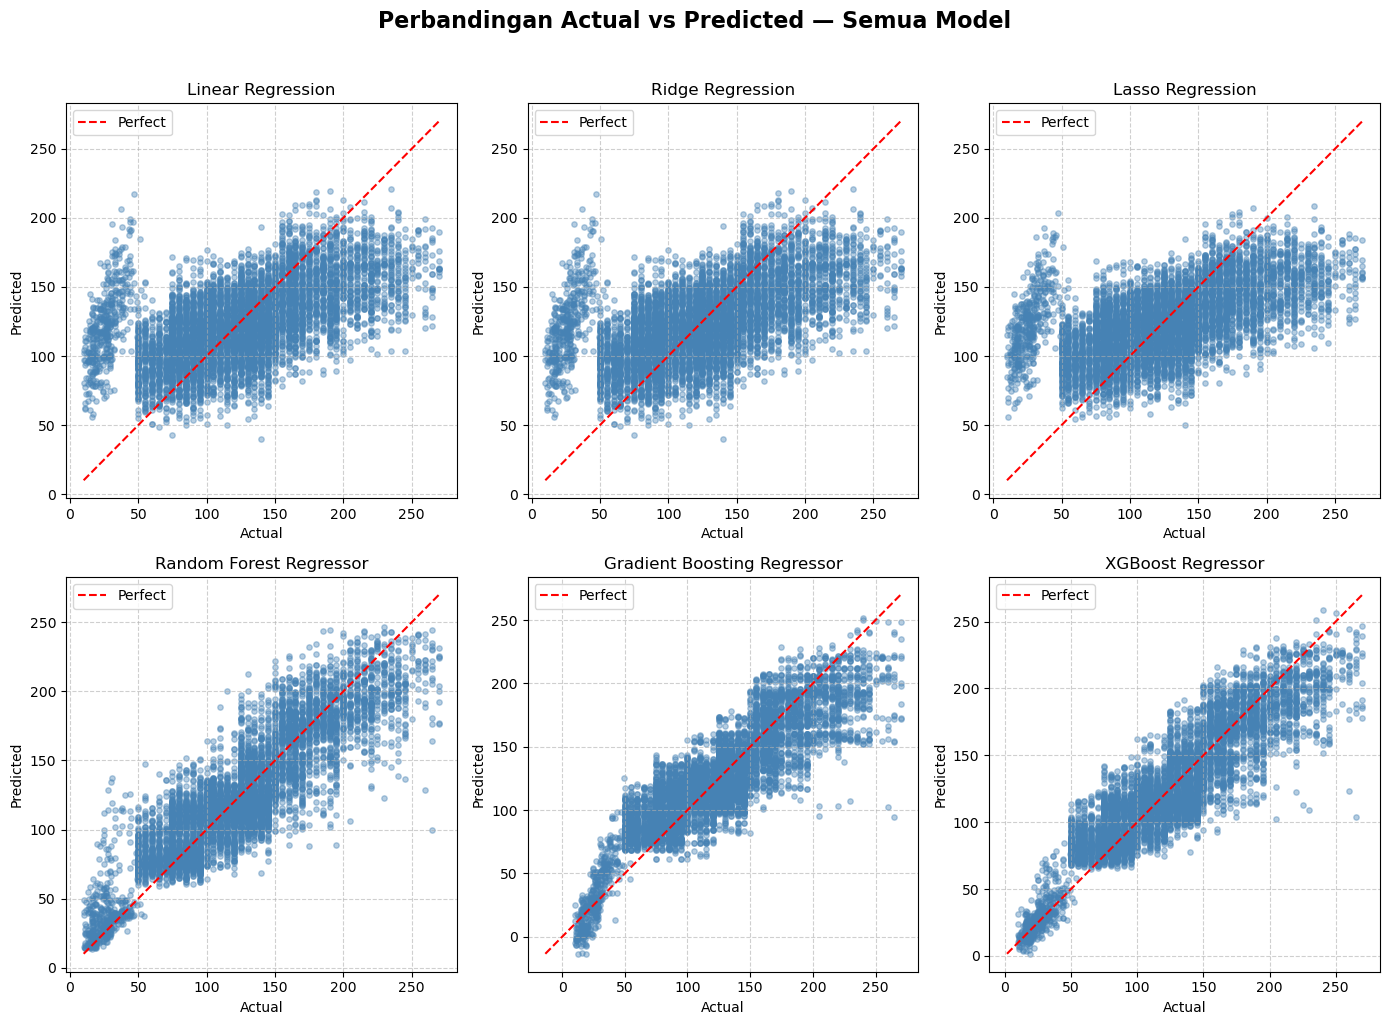

In [31]:
plot_all_modelsRegression_predictions( models_dict=regresi_pipelines, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test,)

In [32]:
## 7. Importance Feature for Models

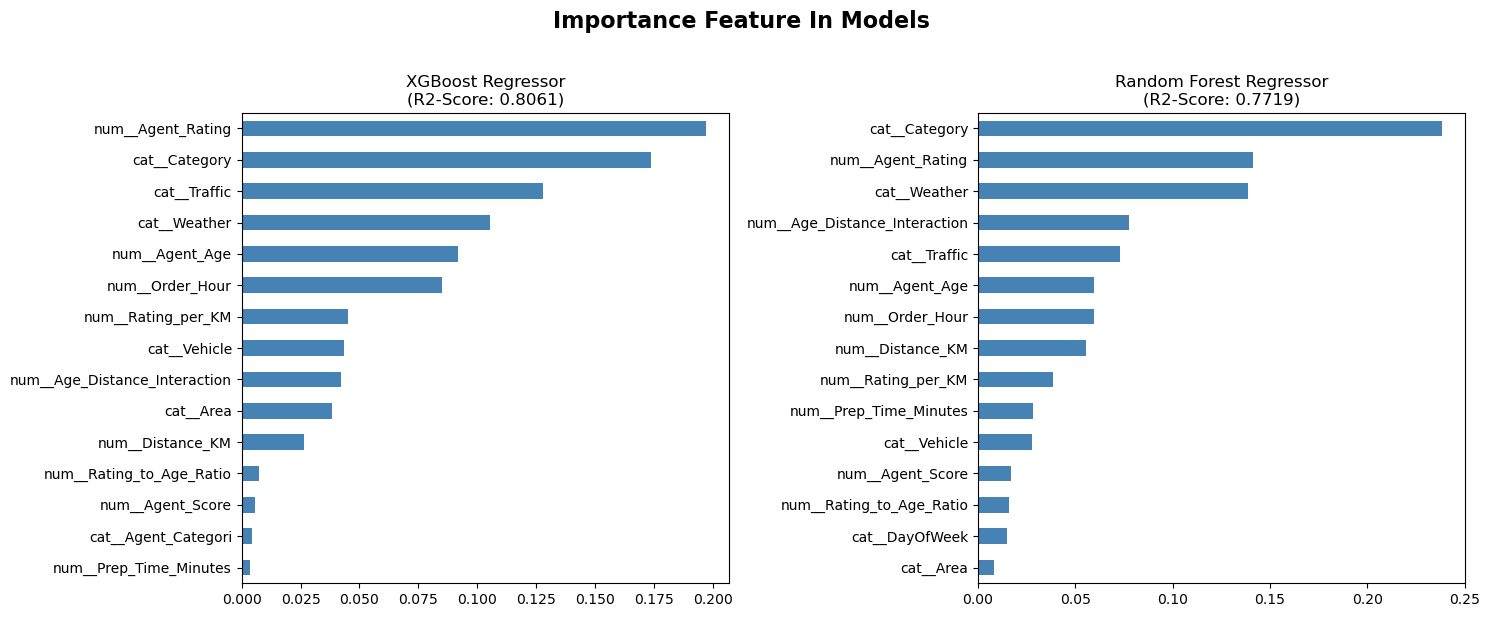

In [33]:
feature_importance(result_crossValidate=df_hasil_perbandingan,model_dict=regresi_pipelines)

## 8. Analysis Residuals — Best Model

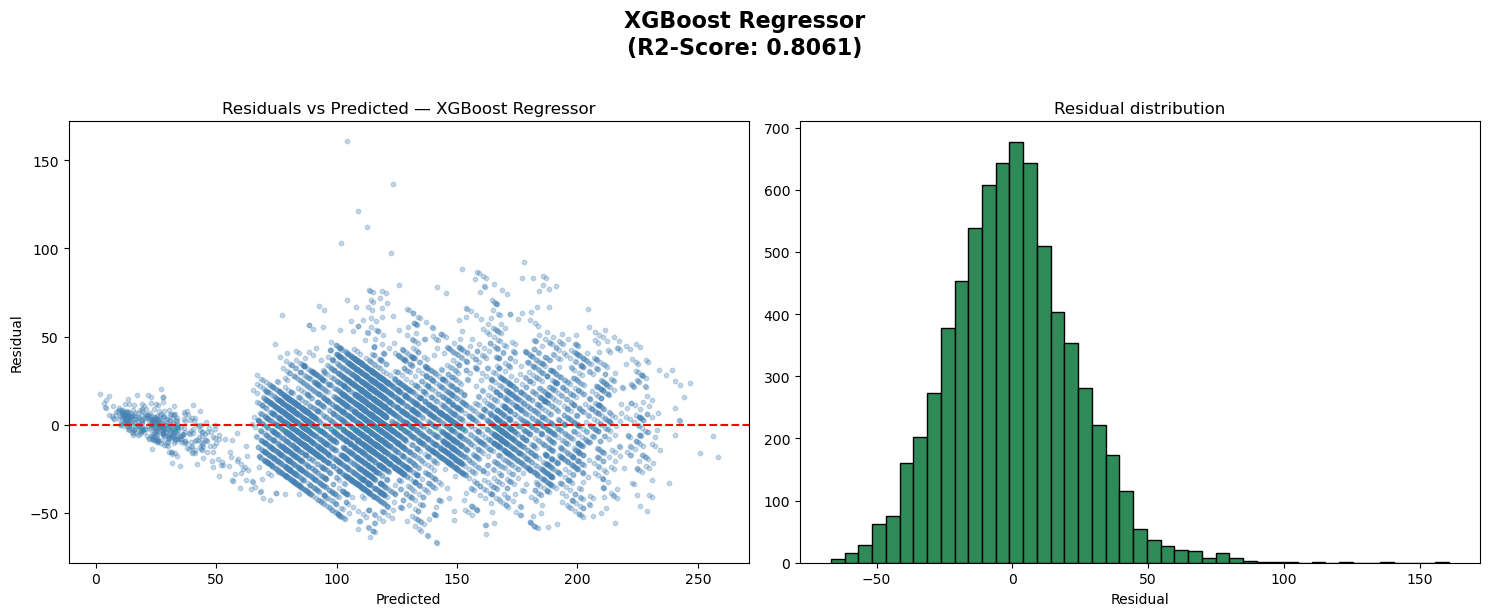

In [35]:
plot_residuals(result_crossValidate=df_hasil_perbandingan,model_dict=regresi_pipelines,x_test=X_test,y_test=y_test)

## 9. Hyperparameter Tuning — Best Performer

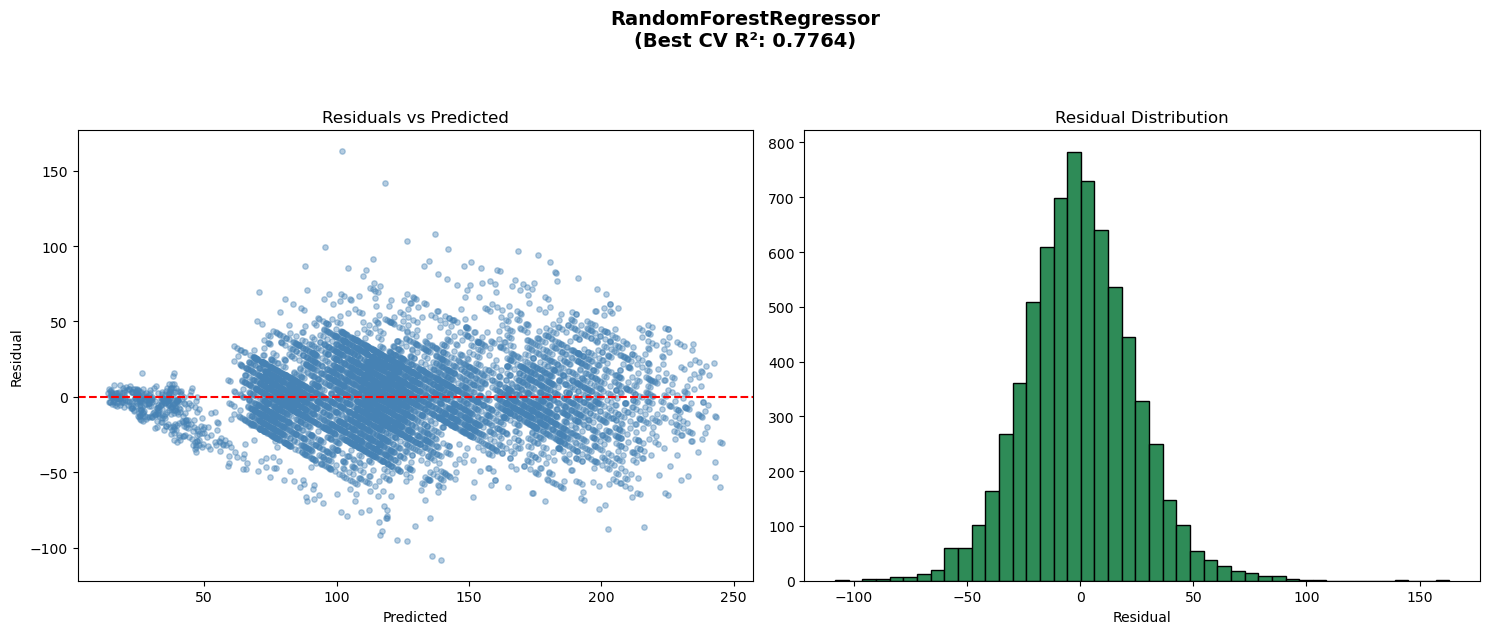

In [37]:
pipeline_model = regresi_pipelines['Random Forest Regressor']
params = {
    'model__n_estimators': [100, 200, 400],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2],
    'model__bootstrap': [True, False]
}
best_model = Hyperparameter_Tuning(method='randomcv',pipeline_model=pipeline_model,cv=5,type_model='regression',
                                   param=params,x_train=X_train,y_train=y_train,x_test=X_test,y_test=y_test)

## 10. Tuned Model — Feature Importance

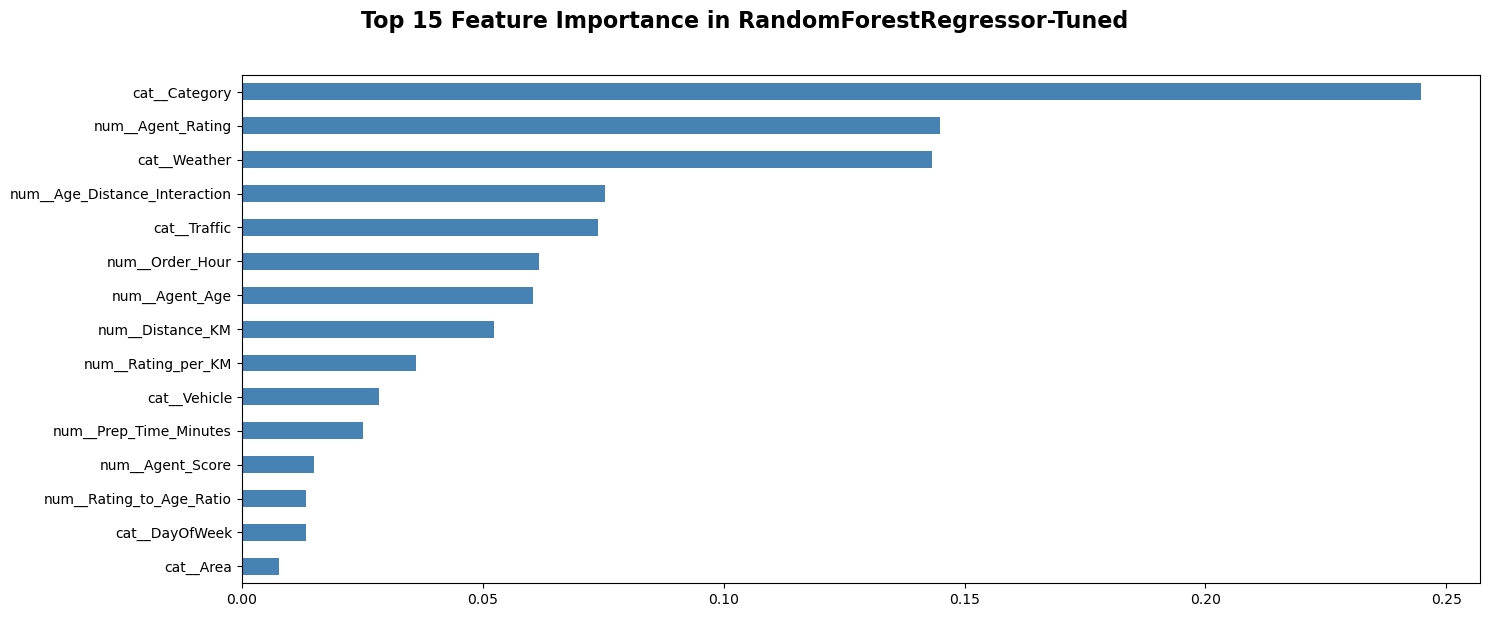

In [39]:
plot_tuned_feature_importance(tuned_model=best_model)

## 11. Simple Prediction

In [41]:
sample = X_test.iloc[:7].copy()
preds = best_model.predict(sample)

result = pd.DataFrame({'Predicted' : preds.round(2),
                       'Actual': y_test.iloc[:7].values.round(2)})
result['AbsError'] = (result['Predicted'] - result['Actual']).abs().round(2)
result

,Predicted,Actual,AbsError
0,140.73,140,0.73
1,164.26,210,45.74
2,84.85,85,0.15
3,101.92,120,18.08
4,143.47,150,6.53
5,99.93,145,45.07
6,120.06,120,0.06


## 12. Save Model

In [43]:
with open('Amanzon_Delivery_Prediction', 'wb') as f:
    pickle.dump(best_model, f)